<a href="https://colab.research.google.com/github/the-craft-labs/training_bactrocera/blob/main/base_training_bactrocera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bactrocera — chia dataset & train YOLO26

Notebook chạy trên **Google Colab**, dữ liệu là bản export **Ultralytics YOLO Detection 1.0** từ CVAT
nằm trên Google Drive.

Hai vấn đề notebook này xử lý:

1. **Leakage.** CVAT dồn 100% ảnh vào một split `train` duy nhất. Notebook chia lại thành train/val/test,
   nhưng gom ảnh gần trùng nhau thành nhóm trước (perceptual hash) — để cùng một tấm dính
   chụp nhiều lần không bị tách sang hai tập khác nhau. Đặt `GROUP_BY="none"` ở mục 1
   nếu muốn chia thuần ngẫu nhiên theo số lượng.

   Không dùng ngày tháng làm căn cứ chia: CVAT strip EXIF khi export, còn `mtime` chỉ là
   thời điểm copy file lên Drive nên vô nghĩa.
2. **I/O.** Không train trực tiếp từ Drive. Drive mount qua FUSE, mỗi epoch YOLO đọc lại toàn bộ ảnh —
   với vài nghìn file nhỏ thì GPU sẽ ngồi chờ I/O. Dữ liệu được copy về `/content` (SSD local) trước.

Ba tập có vai trò khác nhau: `train` để học, `val` để Ultralytics chấm sau mỗi epoch — `patience`
và việc chọn `best.pt` đều đọc từ đây — còn `test` không được đụng tới trong suốt quá trình train,
nên metric trên nó mới là ước lượng sạch để đưa vào nghiệm thu.

`SPLITS` là dict, muốn bỏ `test` để dồn dữ liệu cho hai tập kia thì xoá key đó là xong —
toàn bộ các mục phía sau chạy generic theo dict này.

Chạy tuần tự từ trên xuống. Sau các bước 0, 4 và 5 có phần **cách đọc kết quả** — đọc trước khi chạy tiếp.

Layout export CVAT mong đợi:

```
<thư mục export>/
├── images/train/   *.jpg
├── labels/train/   *.txt
├── data.yaml
└── train.txt       (không dùng)
```

## 0. Kết nối Drive và kiểm tra export CVAT

In [24]:
!pip install -q -U ultralytics

In [25]:
from google.colab import drive
from pathlib import Path
from collections import Counter
from PIL import Image
import random, shutil, csv, json, yaml, time
import numpy as np

drive.mount('/content/drive')

DRIVE  = Path('/content/drive/MyDrive/COLAB/bactrocera')
EXPORT = DRIVE / 'data'      # ← thư mục export CVAT trên Drive; sửa nếu tên khác

assert EXPORT.exists(), f"Không thấy {EXPORT} — kiểm tra lại tên thư mục"

print("── cấu trúc export ──")
for p in sorted(EXPORT.rglob('*')):
    d = len(p.relative_to(EXPORT).parts)
    if d > 2:
        continue
    if p.is_dir():
        print("  " * (d - 1) + f"{p.name}/  ({sum(1 for _ in p.iterdir())} mục)")
    elif d == 1:
        print("  " * (d - 1) + p.name)

for sub_ in ('images', 'labels'):
    dd = EXPORT / sub_
    if dd.exists():
        print(f"\n{sub_}/ :", dict(Counter(p.suffix.lower() for p in dd.rglob('*') if p.is_file())))

print("\n── data.yaml ──")
print(yaml.safe_load((EXPORT / 'data.yaml').read_text()))

lbls = sorted((EXPORT / 'labels').rglob('*.txt')) if (EXPORT / 'labels').exists() else []
if lbls:
    print(f"\n── {lbls[0].name} (3 dòng đầu) ──")
    print("\n".join(lbls[0].read_text().splitlines()[:3]) or "(rỗng)")
else:
    print("\n⚠️  KHÔNG có labels/ — export lại trên CVAT:")
    print("    Export dataset → 'Ultralytics YOLO Detection 1.0' → tick 'Save images'")

import ultralytics
print("\nultralytics:", ultralytics.__version__)
import torch
if not torch.cuda.is_available():
    raise RuntimeError(
        'Runtime đang ở CPU. Runtime → Change runtime type → T4 GPU → Save, '
        'rồi chạy lại TỪ CELL NÀY (đổi runtime là mất mount Drive và xoá /content).'
    )
print('GPU:', torch.cuda.get_device_name(0),
      f'| {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
── cấu trúc export ──
data.yaml
images/  (1 mục)
  train/  (503 mục)
labels/  (2 mục)
  train/  (502 mục)
train.txt

images/ : {'.jpg': 503}

labels/ : {'': 1, '.txt': 502}

── data.yaml ──
{'names': {0: 'bactrocera_dorsalis', 1: 'zonata'}, 'path': '.', 'train': 'train.txt'}

── 20260623_151216.txt (3 dòng đầu) ──
0 0.342617 0.744225 0.151367 0.083300
0 0.674583 0.398150 0.126567 0.098650
0 0.799867 0.430962 0.132467 0.109575

ultralytics: 8.4.142
GPU: Tesla T4 | 15.6 GB


### Cách đọc kết quả

| Thấy gì | Nghĩa là | Làm gì |
|---|---|---|
| không có `labels/` | export nhầm chế độ, chưa kèm annotation | export lại trên CVAT |
| số `.txt` lệch nhiều so với số `.jpg` | một phần ảnh chưa được annotate | về CVAT hoàn tất, hoặc chấp nhận chúng thành ảnh nền |
| dòng label mẫu có ≠ 5 số | không phải format detection (có thể là segmentation/OBB) | export lại đúng **Detection 1.0** |
| `nvidia-smi` báo lỗi | runtime đang ở CPU | Runtime → Change runtime type → GPU |
| `ultralytics` < 8.4 | bản cũ không nhận `yolo26s.pt` | bỏ comment dòng `pip install -U` ở đầu cell, chạy lại, Restart runtime |

GPU T4 (16GB) chạy được `BATCH=8, IMGSZ=960`. L4 hoặc A100 thì nâng `BATCH` lên 16.

## 1. Cấu hình

In [26]:
# ── đường dẫn làm việc ──
SRC = Path('/content/dataset')          # bản copy local của export CVAT
DST = Path('/content/dataset_split')    # kết quả chia tập — phải nằm local, KHÔNG để trên Drive

# ── class: đọc từ data.yaml của CVAT thay vì gõ tay, tránh lệch thứ tự class id ──
_n = yaml.safe_load((EXPORT / 'data.yaml').read_text())['names']
CLASSES = [_n[i] for i in sorted(_n)] if isinstance(_n, dict) else list(_n)

SPLITS = {"train": 0.70, "val": 0.20, "test": 0.10}   # xoá key "test" nếu muốn chia 2 tập
SEED  = 42

# ── gom nhóm chống leakage ──
GROUP_BY        = "hash"  # "hash": gom ảnh gần trùng rồi chia theo nhóm (chống leakage)
                          # "none": chia thuần ngẫu nhiên theo số lượng
USE_FOLDER      = False   # True nếu thư mục con tương ứng bẫy / đợt chụp
DHASH_MAX_DIST  = 12      # chỉ dùng khi GROUP_BY="hash"; chỉnh theo bảng quét ở mục 4
LINKAGE         = "complete"   # "complete": mọi cặp trong cụm phải dưới ngưỡng (khuyến nghị)
                              # "single":   chỉ cần 1 cặp — dễ nối dây chuyền thành 1 cụm khổng lồ

# ── train ──
MODEL    = "yolo26s.pt"   # yolo26n nếu cần nhẹ; yolo26m nếu GPU dư
IMGSZ    = 960
EPOCHS   = 300
BATCH    = 8
PATIENCE = 50             # early stopping
DEVICE   = 0 if torch.cuda.is_available() else "cpu"

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
random.seed(SEED); np.random.seed(SEED)
print("CLASSES =", CLASSES)
print("SPLITS =", SPLITS, "| GROUP_BY =", GROUP_BY, "| DEVICE =", DEVICE)
print("SRC =", SRC)

CLASSES = ['bactrocera_dorsalis', 'zonata']
SPLITS = {'train': 0.7, 'val': 0.2, 'test': 0.1} | GROUP_BY = hash | DEVICE = 0
SRC = /content/dataset


## 2. Copy dữ liệu về `/content`

In [27]:
if SRC.exists():
    shutil.rmtree(SRC)

t = time.time()
!cp -r "{EXPORT}" "{SRC}"
print(f"copy xong sau {time.time()-t:.0f}s")

n_img = sum(1 for p in (SRC / 'images').rglob('*') if p.suffix.lower() in IMG_EXT)
n_lbl = sum(1 for _ in (SRC / 'labels').rglob('*.txt'))
print(f"ảnh  : {n_img}")
print(f"label: {n_lbl}")
assert n_img > 0, "Không có ảnh — kiểm tra lại EXPORT"

copy xong sau 15s
ảnh  : 503
label: 502


Nếu `cp -r` mất trên ~5 phút, nén một lần trên Drive rồi các phiên sau chỉ giải nén — nhanh hơn nhiều
vì Drive tính latency theo từng file:

```python
# chạy MỘT LẦN
!cd "{DRIVE}" && zip -q -r -0 image.zip image
# các phiên sau thay cell trên bằng dòng này
!unzip -q "{DRIVE}/image.zip" -d /content/ && mv /content/image /content/dataset
```

`SRC` trỏ vào **gốc export** (thư mục chứa `images/`, `labels/`, `data.yaml`), không phải vào `images/`.
Notebook tự nối `SRC/"images"` và `SRC/"labels"`; hàm `find_label()` ở bước 5 đã có nhánh tìm trong
thư mục con `train/` nên layout CVAT chạy thẳng, không cần phẳng hoá.

## 3. Quét ảnh

In [28]:
imgs = sorted(p for p in (SRC / "images").rglob("*") if p.suffix.lower() in IMG_EXT)
assert imgs, f"Không tìm thấy ảnh trong {SRC/'images'}"

recs = []
for p in imgs:
    with Image.open(p) as im:
        wh = im.size
    recs.append({"path": p, "wh": wh,
                 "folder": p.parent.relative_to(SRC / "images").as_posix() or "."})

n = len(recs)
print("tổng ảnh     :", n)
print("đuôi file    :", dict(Counter(p.suffix.lower() for p in imgs)))
print("độ phân giải :", Counter(r["wh"] for r in recs).most_common(5))
print("thư mục con  :", Counter(r["folder"] for r in recs).most_common(10))

tổng ảnh     : 503
đuôi file    : {'.jpg': 503}
độ phân giải : [((3000, 4000), 271), ((3024, 4032), 177), ((3072, 4096), 27), ((2268, 4032), 20), ((6120, 8160), 8)]
thư mục con  : [('train', 503)]


### Cách đọc kết quả

| Thấy gì | Nghĩa là | Làm gì |
|---|---|---|
| `thư mục con` chia thành các nhóm rõ ràng | rất có thể tương ứng bẫy hoặc đợt chụp — tín hiệu đáng tin hơn hash | đặt `USE_FOLDER = True` ở mục 1 |
| `thư mục con` chỉ có mỗi `train` | layout CVAT mặc định, không có tín hiệu gì để gom | để `USE_FOLDER = False`, dựa vào hash ở mục 4 |
| `độ phân giải` nhiều loại | dữ liệu trộn từ nhiều máy | ghi nhận lại, sau này đối chiếu với ảnh OV5640 |

Không có cột ngày tháng ở đây là cố ý. CVAT strip EXIF khi export, còn `mtime` chỉ là thời điểm file
được copy lên Drive — mọi ảnh cách nhau vài giây, dùng làm căn cứ chia là sai.

## 4. Gom nhóm ảnh liên quan

In [29]:
if GROUP_BY == "none":
    groups = {i: [r["path"]] for i, r in enumerate(recs)}
    print("GROUP_BY='none' — mỗi ảnh một nhóm, chia thuần ngẫu nhiên theo số lượng.")
    print("⚠️  ảnh gần trùng có thể rơi vào hai tập khác nhau → metric sẽ lạc quan hơn thực tế.")

else:
    from scipy.cluster.hierarchy import linkage, fcluster
    from scipy.spatial.distance import squareform

    def dhash(p, size=8):
        with Image.open(p) as im:
            a = np.asarray(im.convert("L").resize((size + 1, size)), dtype=np.int16)
        return np.packbits((a[:, 1:] > a[:, :-1]).ravel())

    # ── ma trận khoảng cách Hamming giữa mọi cặp ảnh (0-64 bit) ──
    H    = np.stack([dhash(r["path"]) for r in recs])
    POPC = np.unpackbits(np.arange(256, dtype=np.uint8)[:, None], axis=1).sum(1).astype(np.uint8)
    D    = np.zeros((n, n), np.uint8)
    for i in range(0, n, 512):
        D[i:i+512] = POPC[H[i:i+512, None, :] ^ H[None, :, :]].sum(-1)

    d = D[np.triu_indices(n, 1)]
    print("khoảng cách dHash giữa mọi cặp ảnh (0-64 bit)")
    print("  min=%d  p1=%.0f  p5=%.0f  p25=%.0f  median=%.0f  p75=%.0f  max=%d"
          % (d.min(), *np.percentile(d, [1, 5, 25, 50, 75]), d.max()))

    # ── quét ngưỡng, so single-linkage với complete-linkage ──
    Dc = D.astype(np.float64)
    np.fill_diagonal(Dc, 0)
    Dc = np.minimum(Dc, Dc.T)                     # ép đối xứng tuyệt đối
    cond = squareform(Dc, checks=False)
    Z = {"single":   linkage(cond, method="single"),
         "complete": linkage(cond, method="complete")}

    print(f"\n{'ngưỡng':>7}{'single':>9}{'complete':>10}   nhóm lớn nhất (complete)")
    for thr in range(2, 26, 2):
        ls = fcluster(Z["single"],   t=thr, criterion="distance")
        lc = fcluster(Z["complete"], t=thr, criterion="distance")
        big = np.bincount(lc).max()
        print(f"{thr:>7}{len(set(ls)):>9}{len(set(lc)):>10}   {big:>5} ({100*big/n:.0f}%)")

    labels = fcluster(Z[LINKAGE], t=DHASH_MAX_DIST, criterion="distance")
    groups = {}
    for i, l in enumerate(labels):
        groups.setdefault(int(l), []).append(recs[i]["path"])
    print(f"\nLINKAGE={LINKAGE}  DHASH_MAX_DIST={DHASH_MAX_DIST}")

# ── tuỳ chọn: nối thêm các nhóm cùng thư mục ──
if USE_FOLDER:
    gid = {}
    for g, ps in groups.items():
        for p in ps:
            gid[p] = g
    parent = {g: g for g in groups}
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    by_folder = {}
    for r in recs:
        by_folder.setdefault(r["folder"], []).append(gid[r["path"]])
    for ids in by_folder.values():
        for j in ids[1:]:
            ra, rb = find(ids[0]), find(j)
            if ra != rb: parent[rb] = ra
    merged = {}
    for g, ps in groups.items():
        merged.setdefault(find(g), []).extend(ps)
    groups = merged

sizes = sorted((len(v) for v in groups.values()), reverse=True)
print(f"{len(groups)} nhóm / {n} ảnh")
print("kích thước nhóm lớn nhất :", sizes[:10])
print("số nhóm chỉ có 1 ảnh     :", sum(1 for s in sizes if s == 1))
print("nhóm lớn nhất chiếm      : %.1f%% dữ liệu" % (100 * sizes[0] / n))

khoảng cách dHash giữa mọi cặp ảnh (0-64 bit)
  min=0  p1=20  p5=24  p25=29  median=32  p75=35  max=52

 ngưỡng   single  complete   nhóm lớn nhất (complete)
      2      436       436       4 (1%)
      4      429       430       4 (1%)
      6      416       419       4 (1%)
      8      407       411       4 (1%)
     10      388       397       4 (1%)
     12      370       382       6 (1%)
     14      341       368       6 (1%)
     16      283       339       6 (1%)
     18      155       293      10 (2%)
     20       33       245      10 (2%)
     22        1       201      11 (2%)
     24        1       167      15 (3%)

LINKAGE=complete  DHASH_MAX_DIST=12
382 nhóm / 503 ảnh
kích thước nhóm lớn nhất : [6, 4, 4, 4, 4, 4, 4, 4, 3, 3]
số nhóm chỉ có 1 ảnh     : 283
nhóm lớn nhất chiếm      : 1.2% dữ liệu


### Đọc bảng quét ngưỡng

Bỏ qua toàn bộ mục này nếu bạn để `GROUP_BY = "none"` — lúc đó mỗi ảnh là một nhóm và việc chia
hoàn toàn theo số lượng.

Cột `single` là cách gom bằng union-find: chỉ cần A giống B, B giống C là cả ba vào chung nhóm,
dù A và C chẳng giống nhau. Với ảnh tấm dính chụp cùng góc, chuỗi đó nối thông cả dataset — đó là
lý do 503 ảnh từng ra đúng 1 nhóm. Cột này thường nhảy thẳng từ `1` sang `n`, không có mức trung
gian dùng được.

Cột `complete` chỉ gom khi **mọi cặp** trong cụm đều dưới ngưỡng, nên không có hiệu ứng dây chuyền
và số nhóm giảm mượt theo ngưỡng. Đây là cột để chọn.

Chọn `DHASH_MAX_DIST` sao cho:

| Điều kiện | Vì sao |
|---|---|
| số nhóm ≥ 10 | dưới mức này tỉ lệ 70/20/10 không đạt được |
| nhóm lớn nhất < 30% dữ liệu | lớn hơn thì nó sẽ nuốt trọn tập train và làm lệch split |
| số nhóm chưa bằng `n` | bằng `n` nghĩa là ngưỡng quá chặt, tương đương `GROUP_BY="none"` |

Ngưỡng hợp lý thường nằm quanh `p1`–`p5` của phân bố in ở trên. Sửa `DHASH_MAX_DIST` ở mục 1
rồi chạy lại **chỉ cell này**.

Nếu quét hết bảng mà không ngưỡng nào thoả cả ba điều kiện, nghĩa là dataset thực sự chỉ chụp
một vài tấm dính. Lúc đó chuyển sang `GROUP_BY = "none"` và ghi rõ trong hồ sơ nghiệm thu rằng
metric có leakage — đó là cách trung thực hơn là giả vờ đã chống được.

## 5. Chia tập và copy kèm đổi tên

In [30]:
def find_label(img):
    rel = img.parent.relative_to(SRC / "images")
    for c in (SRC / "labels" / f"{img.stem}.txt",
              SRC / "labels" / rel / f"{img.stem}.txt",
              img.with_suffix(".txt")):
        if c.exists():
            return c
    return None

# chia tham lam: nhóm lớn xếp trước, luôn bỏ vào tập đang thiếu nhất
keys = list(groups)
random.Random(SEED).shuffle(keys)
keys.sort(key=lambda k: -len(groups[k]))

target  = {s: n * f for s, f in SPLITS.items()}
buckets = {s: [] for s in target}
filled  = {s: 0 for s in target}
for k in keys:
    s = max(target, key=lambda x: target[x] - filled[x])
    buckets[s].append(k); filled[s] += len(groups[k])

if DST.exists():
    shutil.rmtree(DST)

mapping, rows = [], []
for split, ks in buckets.items():
    (DST / "images" / split).mkdir(parents=True, exist_ok=True)
    (DST / "labels" / split).mkdir(parents=True, exist_ok=True)
    n_img = n_box = n_bg = 0
    for gi, k in enumerate(ks):
        for ii, img in enumerate(sorted(groups[k])):
            new = f"{split[:2]}_{gi:04d}_{ii:03d}"
            shutil.copy2(img, DST / "images" / split / f"{new}{img.suffix.lower()}")
            lbl = find_label(img)
            out = DST / "labels" / split / f"{new}.txt"
            if lbl:
                shutil.copy2(lbl, out)
                n_box += sum(1 for l in out.read_text().splitlines() if l.strip())
            else:
                out.write_text("")          # ảnh nền — YOLO coi là negative sample
                n_bg += 1
            n_img += 1
            mapping.append([split, gi, f"{new}{img.suffix.lower()}", str(img)])
    rows.append((split, len(ks), n_img, n_box, n_bg))

with open(DST / "mapping.csv", "w", newline="", encoding="utf-8") as f:
    csv.writer(f).writerows([["split", "group", "new_name", "original_path"]] + mapping)

empty = [s for s, g, i, *_ in rows if i == 0]
if empty:
    raise RuntimeError(
        f"Tập rỗng: {empty}. Chỉ có {len(groups)} nhóm cho {n} ảnh — không đủ để chia. "
        f"Quay lại mục 4: hạ DHASH_MAX_DIST, hoặc đặt GROUP_BY='none' ở mục 1 để chia thuần ngẫu nhiên."
    )
if len(groups) < 10:
    print(f"⚠️  chỉ {len(groups)} nhóm — tỉ lệ split sẽ lệch nhiều so với {SPLITS}")

print(f"{'split':<7}{'groups':>8}{'images':>8}{'%':>7}{'boxes':>9}{'no_label':>10}")
for s, g, i, b, bg in rows:
    print(f"{s:<7}{g:>8}{i:>8}{100*i/n:>6.1f}%{b:>9}{bg:>10}")
print("\nmapping.csv →", (DST / 'mapping.csv').resolve())

split    groups  images      %    boxes  no_label
train       231     352  70.0%      617         1
val         101     101  20.1%      213         0
test         50      50   9.9%       91         0

mapping.csv → /content/dataset_split/mapping.csv


### Kiểm hai thứ ở bảng trên

1. **Cột `%`** có bám sát `SPLITS` không. Lệch nhiều nghĩa là một nhóm khổng lồ đã nuốt cả tập — quay lại mục 4 siết `DHASH_MAX_DIST`.
2. **Cột `no_label`** — nếu bằng đúng số ảnh thì `find_label()` không tìm ra file `.txt`. Kiểm tra lại cấu trúc thư mục `labels/` và sửa hàm trước khi train.

Cell raise nếu có tập rỗng. Với 3 tập thì `test` ở 10% là chỗ dễ rỗng nhất — nó được cấp hạn ngạch nhỏ nhất nên khi số nhóm ít, vòng chia tham lam có thể không rót được nhóm nào vào đó. Gặp trường hợp này thì xoá key `"test"` trong `SPLITS` ở mục 1 và chạy lại, đừng hạ tỉ lệ xuống thấp hơn nữa.

Dưới 10 nhóm thì tỉ lệ 70/20/10 không đạt được, và mAP đo trên tập vài ảnh không nói lên nhiều điều — vấn đề lúc ấy là dataset chưa đủ đa dạng về tấm dính, không phải code chia sai.

`mapping.csv` giữ liên kết tên mới ↔ đường dẫn gốc, ghép thẳng vào `manifest.json` cho phần nghiệm thu.

## 6. Validate label và đo kích thước vật thể

In [31]:
bad, areas = [], []
for split in SPLITS:
    for lp in sorted((DST / "labels" / split).glob("*.txt")):
        for ln, line in enumerate(lp.read_text().splitlines(), 1):
            t = line.split()
            if not t:
                continue
            if len(t) != 5:
                bad.append((split, lp.name, ln, f"{len(t)} cột thay vì 5")); continue
            try:
                cid = int(float(t[0])); x, y, w, h = map(float, t[1:])
            except ValueError:
                bad.append((split, lp.name, ln, "không parse được số")); continue
            if not 0 <= cid < len(CLASSES):
                bad.append((split, lp.name, ln, f"class id {cid} ngoài phạm vi"))
            if not all(0.0 <= v <= 1.0 for v in (x, y, w, h)):
                bad.append((split, lp.name, ln, "toạ độ ngoài [0,1] — có thể chưa normalize"))
            if w <= 0 or h <= 0:
                bad.append((split, lp.name, ln, "box rỗng"))
            else:
                areas.append((w * h) ** 0.5 * IMGSZ)     # cạnh tương đương, px @ IMGSZ

print(f"{len(bad)} dòng lỗi")
for r in bad[:20]:
    print("  ", r)
if len(bad) > 20:
    print(f"   ... còn {len(bad)-20} dòng")

if areas:
    a = np.array(areas)
    q = np.percentile(a, [5, 25, 50, 75, 95])
    print(f"\n{len(a)} box | cạnh tương đương @ imgsz={IMGSZ} (px)")
    print("  p5=%.1f  p25=%.1f  median=%.1f  p75=%.1f  p95=%.1f" % tuple(q))
    print("  box < 16px: %.1f%%   |   box < 32px: %.1f%%" % (100*(a<16).mean(), 100*(a<32).mean()))

0 dòng lỗi

921 box | cạnh tương đương @ imgsz=960 (px)
  p5=37.1  p25=61.7  median=86.2  p75=121.1  p95=287.1
  box < 16px: 0.0%   |   box < 32px: 3.1%


### Chọn `IMGSZ` theo median

| Median cạnh box | Hành động |
|---|---|
| > 32 px | `yolo26s.pt`, `IMGSZ=960` là đủ |
| 16 – 32 px | nâng `IMGSZ` lên 1280, giảm `BATCH` xuống 4 |
| < 16 px | `IMGSZ=1280` + cân nhắc `yolo26m.pt` |

YOLO26 có **STAL** (Small-Target-Aware Label Assignment) giữ độ phủ positive label cho vật thể nhỏ,
nên với ruồi cỡ 20–30px thường không cần đổi kiến trúc như các đời trước. Cứ chạy baseline
`yolo26s.pt` ở `IMGSZ=960` trước, chỉ nâng khi số liệu ở trên nói phải nâng.

Nếu `% box < 16px` cao, đừng cố bù bằng epoch nhiều hơn — độ phân giải đầu vào mới là thứ chặn trần.

## 7. Xem thử ảnh kèm box

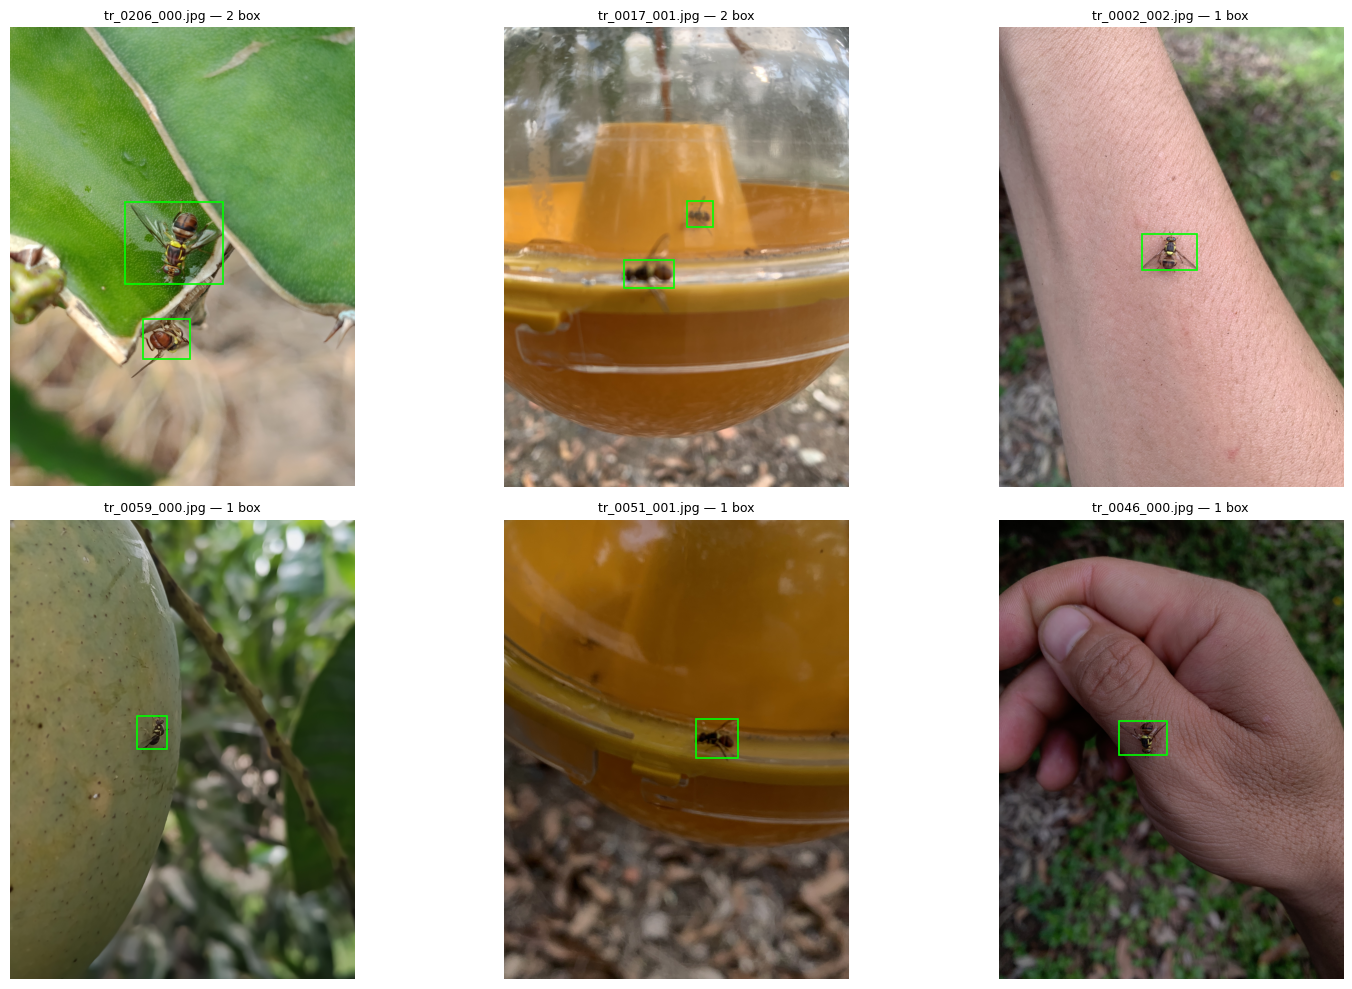

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pool   = sorted((DST / "images" / "train").glob("*"))
sample = random.Random(SEED).sample(pool, k=min(6, len(pool)))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, p in zip(axes.ravel(), sample):
    with Image.open(p) as im:
        W, H = im.size
        ax.imshow(im)
    lp = DST / "labels" / "train" / f"{p.stem}.txt"
    k = 0
    if lp.exists():
        for line in lp.read_text().splitlines():
            t = line.split()
            if len(t) != 5:
                continue
            _, x, y, w, h = (float(v) for v in t)
            ax.add_patch(mpatches.Rectangle(((x-w/2)*W, (y-h/2)*H), w*W, h*H,
                                            fill=False, lw=1.2, edgecolor="lime"))
            k += 1
    ax.set_title(f"{p.name} — {k} box", fontsize=9)
    ax.axis("off")
for ax in axes.ravel()[len(sample):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

Box phải ôm đúng con ruồi. Nếu box lệch hệ thống hoặc lật trục, file `.txt` đang ở format khác
(Pascal VOC pixel, hoặc `x1 y1 x2 y2`) chứ không phải YOLO normalized — phải convert trước khi train.

## 8. Sinh data.yaml

In [33]:
data_yaml = DST / "data.yaml"
data_yaml.write_text(yaml.safe_dump({
    "path":  str(DST.resolve()),
    **{s: f"images/{s}" for s in SPLITS},
    "names": {i: c for i, c in enumerate(CLASSES)},
}, sort_keys=False, allow_unicode=True), encoding="utf-8")

print(data_yaml.read_text(encoding="utf-8"))

path: /content/dataset_split
train: images/train
val: images/val
test: images/test
names:
  0: bactrocera_dorsalis
  1: zonata



## 9. Train — early stopping + LR scheduling + EMA

Ba cơ chế tương ứng:

- **Early stopping** — `patience`: dừng nếu *fitness* không cải thiện sau N epoch.
- **LR scheduling** — `cos_lr` + `lrf`: cosine decay xuống `lr0 * lrf`, có warmup ở đầu.
- **EMA** — bật mặc định trong Ultralytics, không có flag tắt. Đây mới là phần *tự cải thiện* thật sự,
  chứ không chỉ chọn checkpoint tốt nhất.

`optimizer="auto"` để Ultralytics tự chọn: **MuSGD** cho run dài (>10.000 iteration) và AdamW cho run ngắn.
Với `EPOCHS=300` trên dataset này sẽ vượt ngưỡng nên nó chọn MuSGD. Đó cũng là lý do **không gõ `lr0` bằng tay** —
`lr0=0.001` là thang của AdamW, đưa vào MuSGD sẽ thấp hơn cả chục lần so với mức cần. Chế độ auto
tự set `lr0` và `momentum` theo optimizer nó chọn.

In [34]:
from ultralytics import YOLO

model = YOLO(MODEL)

results = model.train(
    data=str(data_yaml),
    project="runs/bactrocera", name="v1", seed=SEED,

    # ── vòng train ──
    epochs=EPOCHS,
    patience=PATIENCE,      # EARLY STOPPING
    batch=BATCH,
    imgsz=IMGSZ,
    device=DEVICE,

    # ── LR SCHEDULING ──
    optimizer="auto",       # tự chọn MuSGD (run dài) hoặc AdamW (run ngắn)
    lrf=0.05,               # LR cuối = lr0 * lrf; lr0 do chế độ auto quyết định
    cos_lr=True,            # cosine decay thay vì linear
    warmup_epochs=3.0,
    warmup_bias_lr=0.1,
    weight_decay=0.0005,

    # ── augmentation ──
    degrees=180,            # ảnh chụp từ trên xuống, không có hướng chuẩn
    flipud=0.5, fliplr=0.5,
    scale=0.5, translate=0.1,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,   # bù chênh lệch màu phone vs OV5640
    mosaic=1.0,
    close_mosaic=15,        # tắt mosaic 15 epoch cuối để hội tụ sạch

    plots=True,
)

RUN  = Path(results.save_dir)
BEST = RUN / "weights" / "best.pt"
LAST = RUN / "weights" / "last.pt"
print("\nrun dir:", RUN.resolve())

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset_split/data.yaml, degrees=180, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1-2, nbs=64, nms=None, opset=None, optimize

## 10. Lưu kết quả về Drive

In [35]:
OUT = DRIVE / 'runs' / RUN.name
OUT.mkdir(parents=True, exist_ok=True)

shutil.copy2(BEST, OUT / 'best.pt')
shutil.copy2(LAST, OUT / 'last.pt')
shutil.copy2(DST / 'mapping.csv', OUT / 'mapping.csv')
shutil.copy2(RUN / 'results.csv', OUT / 'results.csv')
for f in RUN.glob('*.png'):
    shutil.copy2(f, OUT / f.name)

print("đã lưu về:", OUT)
for f in sorted(OUT.iterdir()):
    print(f"  {f.name:<24}{f.stat().st_size/1e6:8.2f} MB")

đã lưu về: /content/drive/MyDrive/COLAB/bactrocera/runs/v1-2
  BoxF1_curve.png             0.11 MB
  BoxPR_curve.png             0.09 MB
  BoxP_curve.png              0.09 MB
  BoxR_curve.png              0.11 MB
  best.pt                    20.36 MB
  confusion_matrix.png        0.12 MB
  confusion_matrix_normalized.png    0.13 MB
  last.pt                    20.36 MB
  mapping.csv                 0.04 MB
  results.csv                 0.03 MB
  results.png                 0.29 MB


`/content` bị xoá sạch khi runtime ngắt, nên chạy cell này **ngay** sau khi train xong.

`mapping.csv` phải copy cùng — không có nó thì lần sau bạn không truy được ảnh nào đã vào tập `test`,
và mọi so sánh giữa các lần train mất ý nghĩa.

## 11. Đọc checkpoint dict

In [36]:
import torch

ckpt = torch.load(BEST, map_location="cpu", weights_only=False)
print("keys:", list(ckpt.keys()))
for k in ("epoch", "best_fitness", "date", "version"):
    print(f"  {k:<13}: {ckpt.get(k)}")
print("\nkích thước file:")
for f in (BEST, LAST):
    print(f"  {f.name:<9} {f.stat().st_size/1e6:6.1f} MB")

keys: ['date', 'version', 'license', 'docs', 'epoch', 'best_fitness', 'model', 'ema', 'updates', 'optimizer', 'scaler', 'train_args', 'train_metrics', 'train_results', 'git']
  epoch        : -1
  best_fitness : None
  date         : 2026-09-06T11:52:23.562723+00:00
  version      : 8.4.142

kích thước file:
  best.pt     20.4 MB
  last.pt     20.4 MB


### Vì sao `best_fitness` và `optimizer` lại ra `None`

File `.pt` là một dict Python. **Trong lúc train** nó gồm `model`, `ema`, `updates`, `optimizer`,
`epoch`, `best_fitness`, `train_args`, `train_metrics`.

Khi train kết thúc, Ultralytics gọi `strip_optimizer()` lên `best.pt` và `last.pt`:
hàm này **ghi đè `model` bằng `ema`**, rồi set `optimizer` / `ema` / `updates` / `best_fitness` về `None`
và `epoch = -1`. Nên `best.pt` bạn cầm về **đã chính là EMA weights** — nhẹ hơn khoảng một nửa và
thường tốt hơn weights gốc. Muốn giữ dict đầy đủ để resume thì phải copy checkpoint ra chỗ khác
*trong lúc* đang train.

`best.pt` được chọn theo **fitness** `= 0.1·mAP50 + 0.9·mAP50-95`, không phải theo loss.

`train_args` giữ nguyên toàn bộ hyperparameter của lần train này — đây là thứ ghi vào bảng `model_runs`
để lần retrain sau tái lập được.

## 12. Đánh giá trên tập test

In [37]:
m   = YOLO(BEST)
res = m.val(data=str(data_yaml), split="test", imgsz=IMGSZ,
            conf=0.001, iou=0.6, max_det=1000)

print(f"mAP50-95 : {res.box.map:.4f}")
print(f"mAP50    : {res.box.map50:.4f}")
print(f"Precision: {res.box.mp:.4f}")
print(f"Recall   : {res.box.mr:.4f}")
print(f"fitness  : {0.1*res.box.map50 + 0.9*res.box.map:.4f}")

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 120 layers, 9,465,954 parameters, 0 gradients, 20.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 235.6±62.5 MB/s, size: 2173.8 KB)
val: Scanning /content/dataset_split/labels/test... 50 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 413.5it/s 0.1s
val: New cache created: /content/dataset_split/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.4s/it 9.5s
                   all         50         91      0.932      0.934      0.956      0.596
   bactrocera_dorsalis         50         91      0.932      0.934      0.956      0.596
Speed: 15.2ms preprocess, 23.5ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val
mAP50-95 : 0.5962
mAP50    : 0.9556
Precision: 0.9319
Recall   : 0.9341
fitness  : 0.6321


## 13. Dò ngưỡng `conf` theo sai số đếm

Bài toán ở đây là **đếm** chứ không phải phát hiện, nên mAP không phải chỉ số cuối cùng.
Cái cần tối ưu là MAE giữa số box dự đoán và số box thật trên mỗi ảnh.

Ngưỡng `conf` tối ưu cho đếm thường **thấp hơn** ngưỡng tối ưu cho F1: false negative
(bỏ sót ruồi) làm lệch đường cong mật độ quần thể nặng hơn false positive, vì sai số bỏ sót
tích lũy theo một hướng qua các ngày còn false positive thì phân tán ngẫu nhiên.

YOLO26 chạy end-to-end, sinh thẳng detection cuối không qua NMS, nên `iou` gần như không còn tác dụng
ở bước này — chỉ còn `conf` là biến phải dò. Đổi lại, khi deploy lên backend bạn bớt được
một tham số phải tune.

In [38]:
test_imgs = sorted((DST / "images" / "test").glob("*"))
gt = np.array([
    sum(1 for l in (DST / "labels" / "test" / f"{p.stem}.txt").read_text().splitlines() if l.strip())
    for p in test_imgs
])

print(f"{'conf':>6}{'MAE':>9}{'bias':>9}{'MAPE':>9}")
best_conf, best_mae = None, float("inf")
for c in np.arange(0.05, 0.65, 0.05):
    preds = m.predict(test_imgs, conf=float(c), iou=0.5, imgsz=IMGSZ,
                      max_det=1000, verbose=False, stream=True)
    pc   = np.array([len(r.boxes) for r in preds])
    mae  = np.abs(pc - gt).mean()
    bias = (pc - gt).mean()
    mape = 100 * (np.abs(pc - gt) / np.maximum(gt, 1)).mean()
    print(f"{c:>6.2f}{mae:>9.2f}{bias:>+9.2f}{mape:>8.1f}%")
    if mae < best_mae:
        best_mae, best_conf = mae, float(c)

print(f"\nconf tối ưu cho đếm: {best_conf:.2f}  (MAE={best_mae:.2f})")
print("→ dùng giá trị này cho inference trên backend, không dùng mặc định 0.25")

  conf      MAE     bias     MAPE
  0.05     0.20    +0.12     8.4%
  0.10     0.08    +0.00     2.8%
  0.15     0.10    -0.02     3.8%
  0.20     0.10    -0.06     3.8%
  0.25     0.12    -0.08     4.5%
  0.30     0.12    -0.08     4.5%
  0.35     0.14    -0.10     5.0%
  0.40     0.14    -0.10     5.0%
  0.45     0.14    -0.14     5.5%
  0.50     0.22    -0.22     9.8%
  0.55     0.24    -0.24    11.8%
  0.60     0.32    -0.32    16.0%

conf tối ưu cho đếm: 0.10  (MAE=0.08)
→ dùng giá trị này cho inference trên backend, không dùng mặc định 0.25


## Bước tiếp theo

- Ghi `best_conf`, `mAP50-95` và `train_args` của checkpoint vào bảng `model_runs`, kèm hash của
  `mapping.csv` để lần retrain sau đối chiếu được đúng tập test.
- Trước khi triển khai: val lại trên một tập nhỏ ảnh chụp bằng **OV5640** thật. Chênh lệch mAP giữa
  ảnh phone và ảnh OV5640 chính là chỉ số đo domain gap — nếu tụt nhiều thì cần fine-tune trên ảnh
  camera thật, augment thêm không giải quyết được.
- Export cho inference: `m.export(format="onnx", imgsz=IMGSZ, simplify=True)`. YOLO26 vốn end-to-end
  nên không cần bật `nms=True` khi export.

# 14

chạy inference trên 50 ảnh test ở conf=0.10 ...


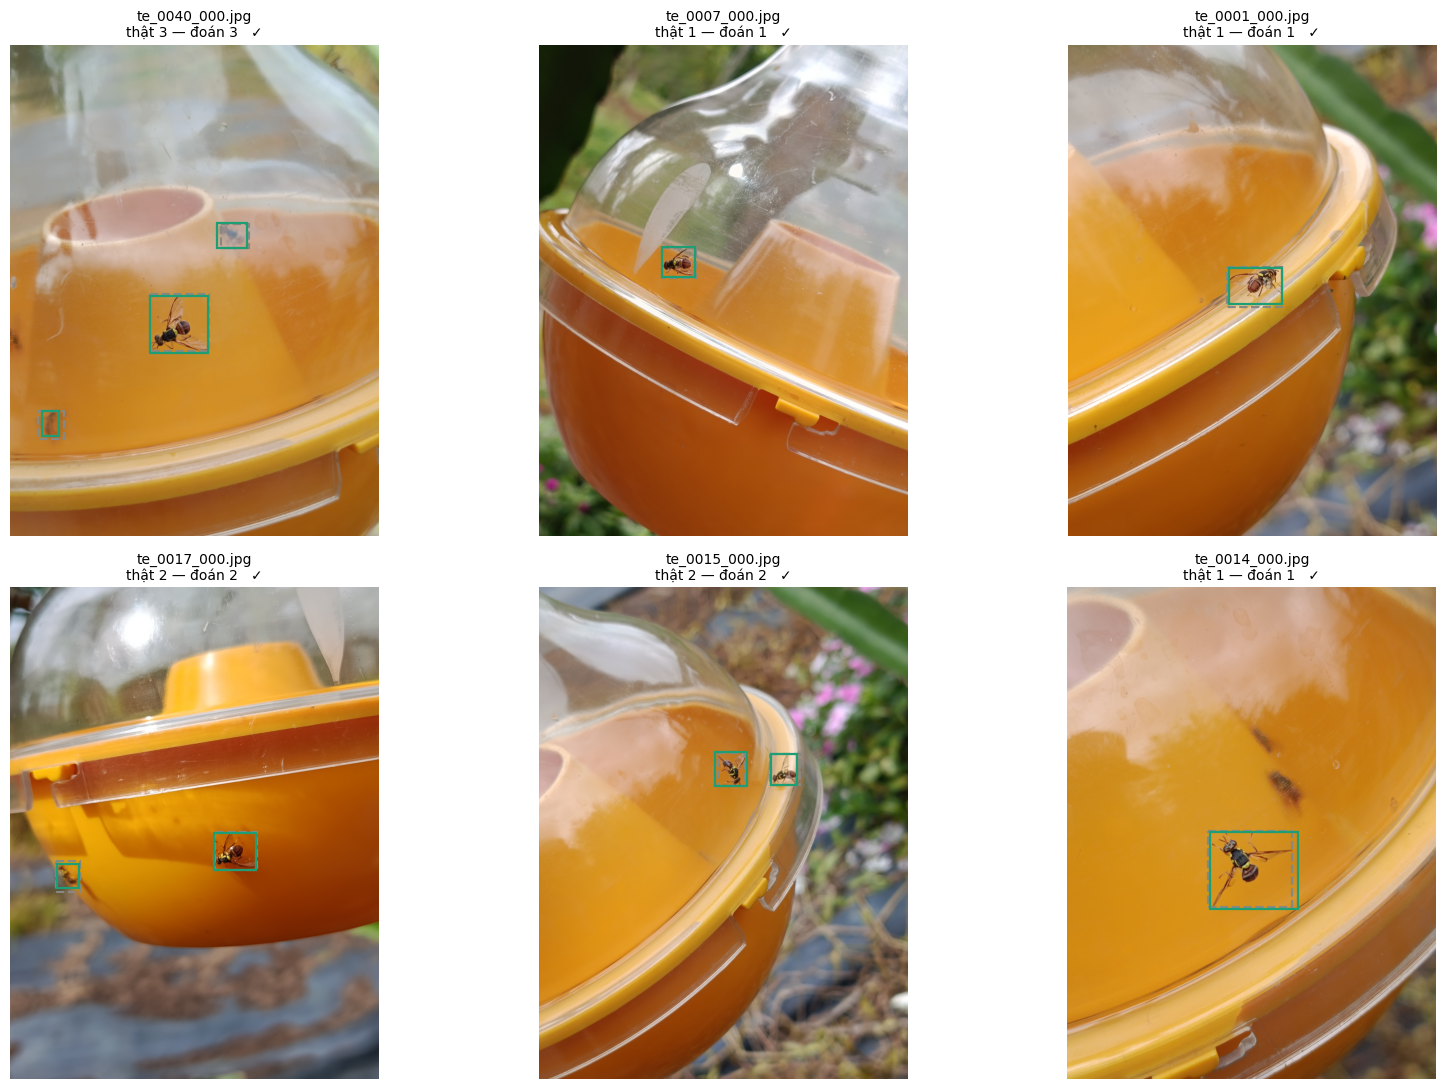

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

CONF   = globals().get("best_conf", 0.25)      # lấy ngưỡng đã dò ở mục 13
COLORS = ["#1D9E75", "#D85A30", "#7F77DD", "#EF9F27"]
m      = YOLO(BEST)

test_imgs = sorted((DST / "images" / "test").glob("*"))
assert test_imgs, "Tập test rỗng"

def gt_count(p):
    lp = DST / "labels" / "test" / f"{p.stem}.txt"
    return sum(1 for l in lp.read_text().splitlines() if l.strip()) if lp.exists() else 0

print(f"chạy inference trên {len(test_imgs)} ảnh test ở conf={CONF:.2f} ...")
preds = m.predict([str(p) for p in test_imgs], conf=CONF, imgsz=IMGSZ,
                  max_det=1000, verbose=False)

def draw(ax, img_path, result, show_gt=True):
    with Image.open(img_path) as im:
        W, H = im.size
        ax.imshow(im)
    n_gt = 0
    lp = DST / "labels" / "test" / f"{img_path.stem}.txt"
    if show_gt and lp.exists():
        for line in lp.read_text().splitlines():
            t = line.split()
            if len(t) != 5:
                continue
            _, x, y, w, h = (float(v) for v in t)
            ax.add_patch(mpatches.Rectangle(((x - w/2)*W, (y - h/2)*H), w*W, h*H,
                         fill=False, lw=1.6, edgecolor="#888880", linestyle="--"))
            n_gt += 1
    for bx in result.boxes:
        x1, y1, x2, y2 = bx.xyxy[0].tolist()
        ci = int(bx.cls[0])
        ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                     lw=1.6, edgecolor=COLORS[ci % len(COLORS)]))
    ax.axis("off")
    return n_gt, len(result.boxes)

idx = random.Random(SEED).sample(range(len(test_imgs)), k=min(6, len(test_imgs)))
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
for ax, i in zip(axes.ravel(), idx):
    g, p = draw(ax, test_imgs[i], preds[i])
    mark = "✓" if g == p else f"{p-g:+d}"
    ax.set_title(f"{test_imgs[i].name}\nthật {g} — đoán {p}   {mark}", fontsize=10)
for ax in axes.ravel()[len(idx):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

# 15

MAE  = 0.24   bias = +0.16   số ảnh đếm đúng tuyệt đối = 40/50

ảnh                           thật  đoán   lệch
te_0035_000.jpg                  3     5     +2
te_0038_000.jpg                  1     3     +2
te_0000_000.jpg                  2     3     +1
te_0002_000.jpg                  4     5     +1
te_0019_000.jpg                  3     2     -1
te_0020_000.jpg                  2     3     +1
te_0022_000.jpg                  1     2     +1
te_0042_000.jpg                  2     1     -1
te_0044_000.jpg                  4     5     +1
te_0047_000.jpg                  1     2     +1


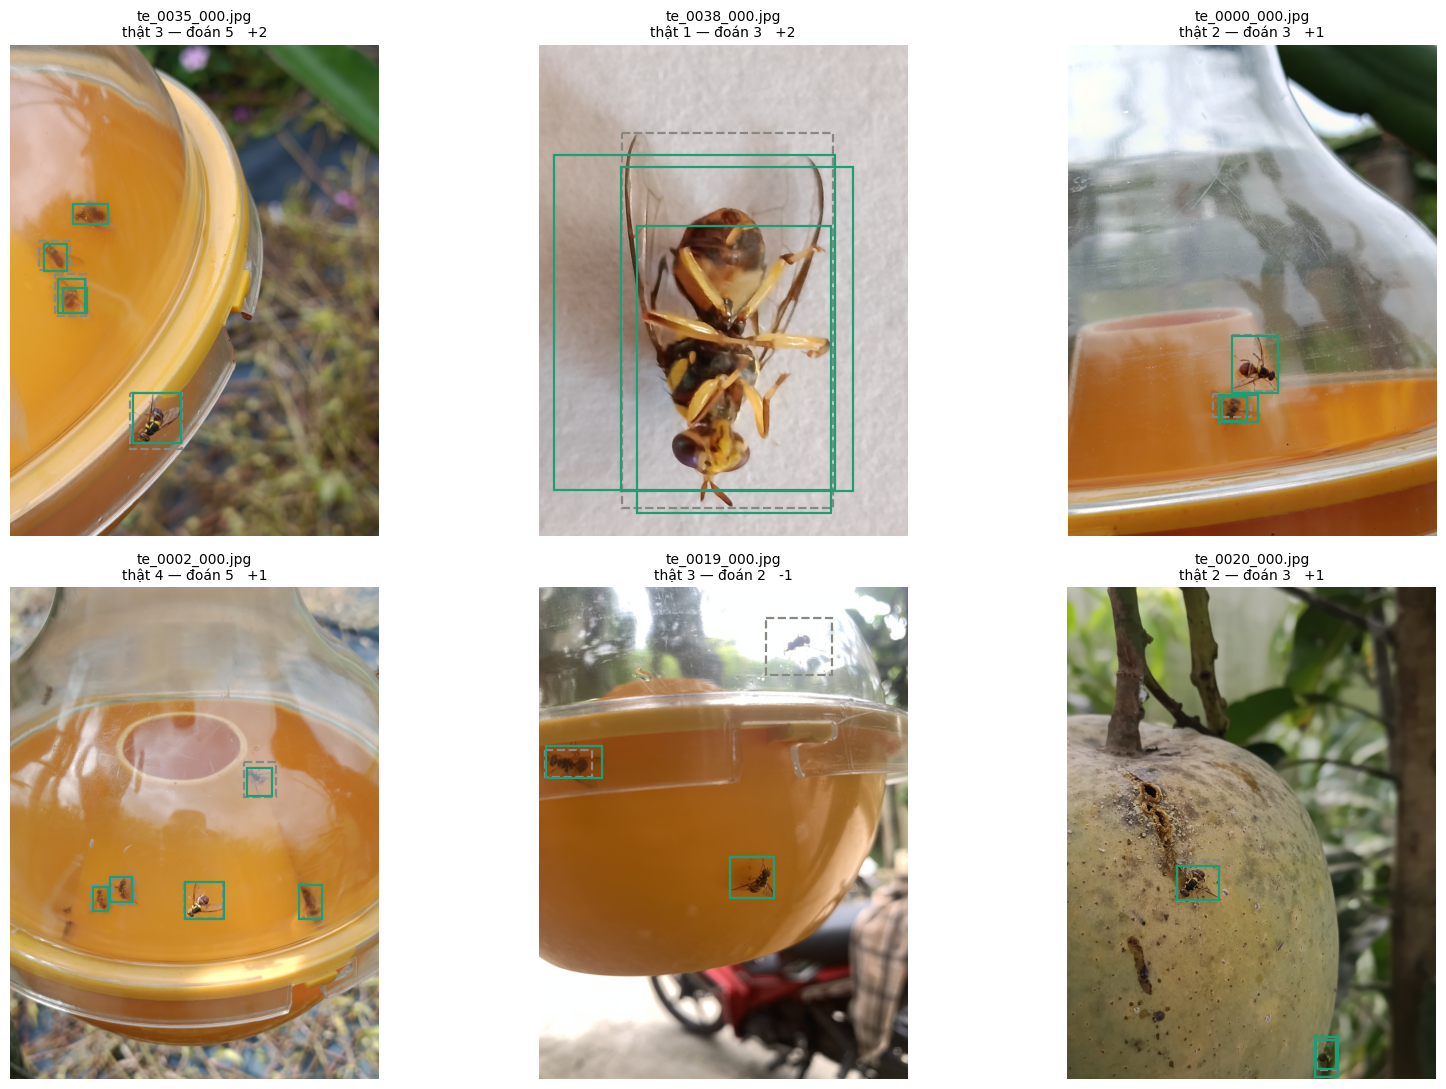

In [40]:
err = []
for p, r in zip(test_imgs, preds):
    g, q = gt_count(p), len(r.boxes)
    err.append((abs(q - g), q - g, g, q, p, r))
err.sort(key=lambda x: -x[0])

d = np.array([e[1] for e in err])
print(f"MAE  = {np.abs(d).mean():.2f}   bias = {d.mean():+.2f}   "
      f"số ảnh đếm đúng tuyệt đối = {(d == 0).sum()}/{len(d)}")
print(f"\n{'ảnh':<28}{'thật':>6}{'đoán':>6}{'lệch':>7}")
for _, diff, g, q, p, _ in err[:10]:
    print(f"{p.name:<28}{g:>6}{q:>6}{diff:>+7}")

k = min(6, len(err))
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
for ax, (_, diff, g, q, p, r) in zip(axes.ravel(), err[:k]):
    draw(ax, p, r)
    ax.set_title(f"{p.name}\nthật {g} — đoán {q}   {diff:+d}", fontsize=10)
for ax in axes.ravel()[k:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

# 16

weights : /content/runs/detect/runs/bactrocera/v1-2/weights/best.pt
classes : {0: 'bactrocera_dorsalis', 1: 'zonata'}
conf    : 0.1 



Saving IMG_20260819_084711.jpg to IMG_20260819_084711.jpg

ảnh                               số con  conf thấp nhất         phân bố class
IMG_20260819_084711.jpg                4           0.119 bactrocera_dorsalis:4


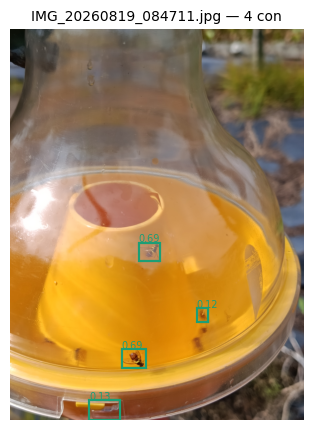

In [42]:
from google.colab import files

WEIGHTS = BEST          # hoặc trỏ tay: DRIVE / "runs" / "v1-2" / "best.pt"
CONF    = globals().get("best_conf", 0.25)
COLORS  = ["#1D9E75", "#D85A30", "#7F77DD", "#EF9F27"]

m = YOLO(WEIGHTS)
print("weights :", WEIGHTS)
print("classes :", m.names)
print("conf    :", CONF, "\n")

up = files.upload()
paths = []
for name, data in up.items():
    p = Path("/content") / name
    p.write_bytes(data)
    if p.suffix.lower() in IMG_EXT:
        paths.append(p)
assert paths, "Không có ảnh hợp lệ nào được upload"

out = m.predict([str(p) for p in paths], conf=CONF, imgsz=IMGSZ,
                max_det=1000, verbose=False)

print(f"\n{'ảnh':<32}{'số con':>8}{'conf thấp nhất':>16}{'phân bố class':>22}")
for p, r in zip(paths, out):
    n  = len(r.boxes)
    cf = f"{float(r.boxes.conf.min()):.3f}" if n else "—"
    if n:
        cnt = {m.names[int(c)]: int((r.boxes.cls == c).sum())
               for c in r.boxes.cls.unique()}
        dist = ", ".join(f"{k}:{v}" for k, v in cnt.items())
    else:
        dist = "—"
    print(f"{p.name:<32}{n:>8}{cf:>16}{dist:>22}")

k    = len(paths)
cols = min(3, k)
rows = (k + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5.6*cols, 4.4*rows), squeeze=False)
flat = axes.ravel()
for ax, p, r in zip(flat, paths, out):
    with Image.open(p) as im:
        ax.imshow(im)
    for bx in r.boxes:
        x1, y1, x2, y2 = bx.xyxy[0].tolist()
        ci, cf = int(bx.cls[0]), float(bx.conf[0])
        ax.add_patch(mpatches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                     lw=1.6, edgecolor=COLORS[ci % len(COLORS)]))
        ax.text(x1, y1-4, f"{cf:.2f}", fontsize=7, color=COLORS[ci % len(COLORS)])
    ax.set_title(f"{p.name} — {len(r.boxes)} con", fontsize=10)
    ax.axis("off")
for ax in flat[k:]:
    ax.axis("off")
plt.tight_layout(); plt.show()